#  AIDI 1100: INTRODUCTION TO AI DEVELOPMENT  
## Final Project  
**Group 8 **  





Extra Mile:
- 5-Year Stock Performance Analysis
- Uploaded the project in Github
- CAGR Calculation



In [9]:
import requests
from bs4 import BeautifulSoup
import csv

# File to store results
csv_file = open('news.csv', mode='w', newline='', encoding='utf-8')
csv_writer = csv.writer(csv_file)

# Write header row
csv_writer.writerow(['Title'])

# Base URL
base_url = 'https://www.prnewswire.com/news-releases/news-releases-list/'

# Number of pages to scrape
num_pages = 25

for page in range(1, num_pages + 1):
    url = base_url if page == 1 else f"{base_url}?page={page}"
    response = requests.get(url)

    if response.status_code != 200:
        print(f"Failed to fetch page {page}")
        continue

    # Parse the HTML
    soup = BeautifulSoup(response.content, 'html.parser')

    # Find and save article titles
    for headline in soup.find_all('h3'):
      title = headline.text.strip()

      # Write to CSV
      csv_writer.writerow([title])

# Close the file when done
csv_file.close()
print("\n Data saved to news.csv")


 Data saved to news.csv


In [10]:
import csv
from collections import defaultdict

#List of AutoManufacturer stocks
stocks =["AIEV", "AYRO", "CENN", "CJET", "CYD", "DMN", "ECDA", "EVTV", "FFAI", "FLYE", "GGR", "GM",
        "HMC", "LCID", "LOBO", "LOT", "LVWR", "MULN", "NIO", "NIU", "NWTN", "PEV", "PSNY", "PSNYW",
        "RACE", "RIVN", "STLA", "TSLA", "VFS", "VLCN", "WKHS", "XPEV", "ZAPP", "ZK"]

# Dictionary to hold counts
string_counts = defaultdict(int)

# Path to CSV file
csv_file_path = 'news.csv'

# Read the CSV and count occurrences
with open(csv_file_path, newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        for cell in row:
            cell_lower = cell.lower()  # Make search case-insensitive
            for stock in stocks:
                string_counts[stock] += cell_lower.count(stock.lower())

# Display the results
for string, count in string_counts.items():
    print(f"'{string}' appears {count} times in the CSV file.")

'AIEV' appears 0 times in the CSV file.
'AYRO' appears 0 times in the CSV file.
'CENN' appears 0 times in the CSV file.
'CJET' appears 0 times in the CSV file.
'CYD' appears 0 times in the CSV file.
'DMN' appears 0 times in the CSV file.
'ECDA' appears 0 times in the CSV file.
'EVTV' appears 0 times in the CSV file.
'FFAI' appears 1 times in the CSV file.
'FLYE' appears 2 times in the CSV file.
'GGR' appears 0 times in the CSV file.
'GM' appears 4 times in the CSV file.
'HMC' appears 0 times in the CSV file.
'LCID' appears 0 times in the CSV file.
'LOBO' appears 0 times in the CSV file.
'LOT' appears 3 times in the CSV file.
'LVWR' appears 0 times in the CSV file.
'MULN' appears 1 times in the CSV file.
'NIO' appears 9 times in the CSV file.
'NIU' appears 2 times in the CSV file.
'NWTN' appears 0 times in the CSV file.
'PEV' appears 0 times in the CSV file.
'PSNY' appears 0 times in the CSV file.
'PSNYW' appears 0 times in the CSV file.
'RACE' appears 0 times in the CSV file.
'RIVN' ap

In [3]:
#Define selected stock symbols and their exchanges

stocks = {
    "GM": "NYSE",      # General Motors
    "MULN": "NASDAQ",  # Mullen Automotive
    "NIO": "NYSE"      # NIO Inc.
}


In [4]:
# Retrieve stock price and volume data using Yahoo Finance API

import yfinance as yf
import pandas as pd

# Prepare an empty list to store all stock data
all_data = []

for symbol, exchange in stocks.items():
    stock = yf.Ticker(symbol)
    # Fetch historical data (get more days to ensure we get 30 trading days)
    hist = stock.history(period="60d").tail(30)  # Ensure we only keep last 30 trading days
    hist.reset_index(inplace=True)
    hist['Symbol'] = symbol
    hist['Exchange'] = exchange
    all_data.append(hist)

# Combine data for all selected stocks
all_data = pd.concat(all_data)

# Save combined data to CSV for record
all_data.to_csv("selected_stocks_data.csv", index=False)
print("Data saved to selected_stocks_data.csv")


Data saved to selected_stocks_data.csv


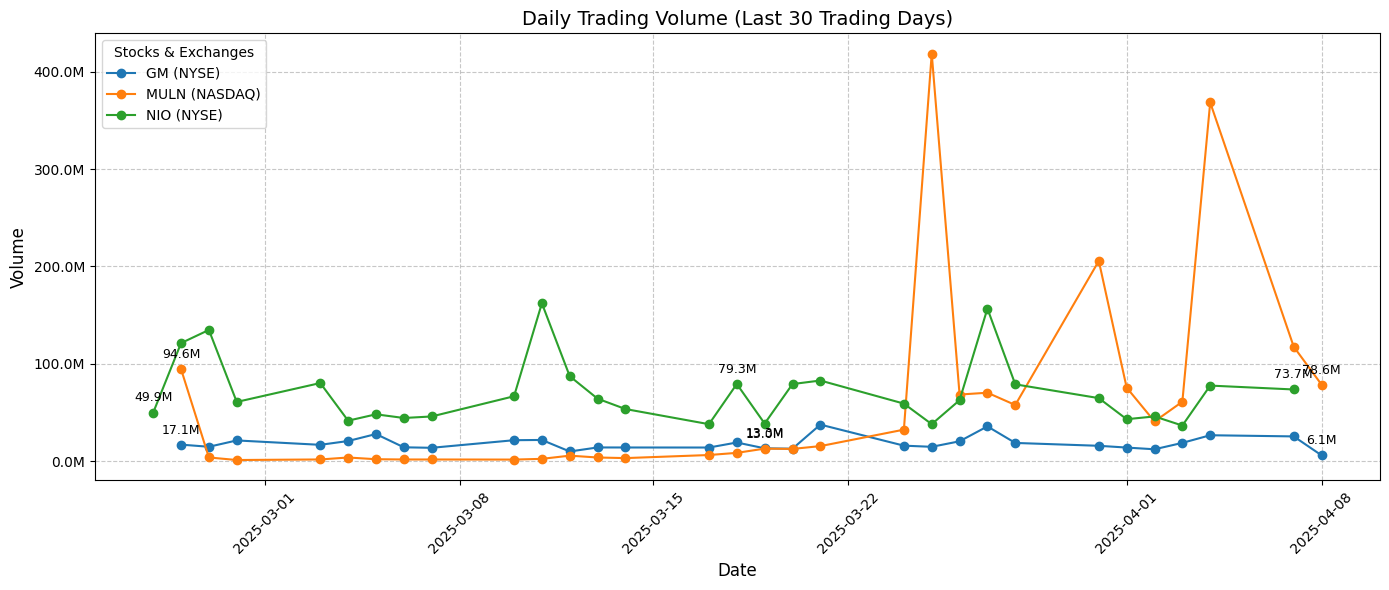

In [5]:
# Import necessary libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Set the figure size for better visibility
plt.figure(figsize=(14, 6))

# Loop through each stock symbol
for symbol in stocks:
    # Filter the dataset for the current stock symbol
    subset = all_data[all_data['Symbol'] == symbol]

    # Plot the Volume data with markers for each point
    plt.plot(subset['Date'], subset['Volume'], label=f"{symbol} ({stocks[symbol]})", marker='o')

    # Identify indices for start, middle, and end positions in the data
    indices = [0, len(subset) // 2, len(subset) - 1]

    # Add annotations to show the volume at start, middle, and end points
    for i in indices:
        plt.annotate(
            f'{subset["Volume"].iloc[i]/1e6:.1f}M',                    # Format volume in millions with 1 decimal
            (subset['Date'].iloc[i], subset['Volume'].iloc[i]),        # Position of the annotation
            textcoords="offset points",                                # Offset the text to avoid overlap
            xytext=(0, 8),                                             # Offset by 8 points vertically
            ha='center',                                               # Horizontal alignment center
            fontsize=9,                                                # Font size of annotation
            color='black'                                              # Annotation color
        )

# Set the title of the graph
plt.title('Daily Trading Volume (Last 30 Trading Days)', fontsize=14)

# Set the x-axis label
plt.xlabel('Date', fontsize=12)

# Set the y-axis label
plt.ylabel('Volume', fontsize=12)

# Format y-axis ticks to show values in millions (e.g., 100M)
ax = plt.gca()  # Get current axis
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x * 1e-6:.1f}M'))

# Add a legend with a title to distinguish between stocks
plt.legend(title='Stocks & Exchanges')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add grid lines to the plot for better visual reference
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent label cut-off
plt.tight_layout()

# Display the plot
plt.show()


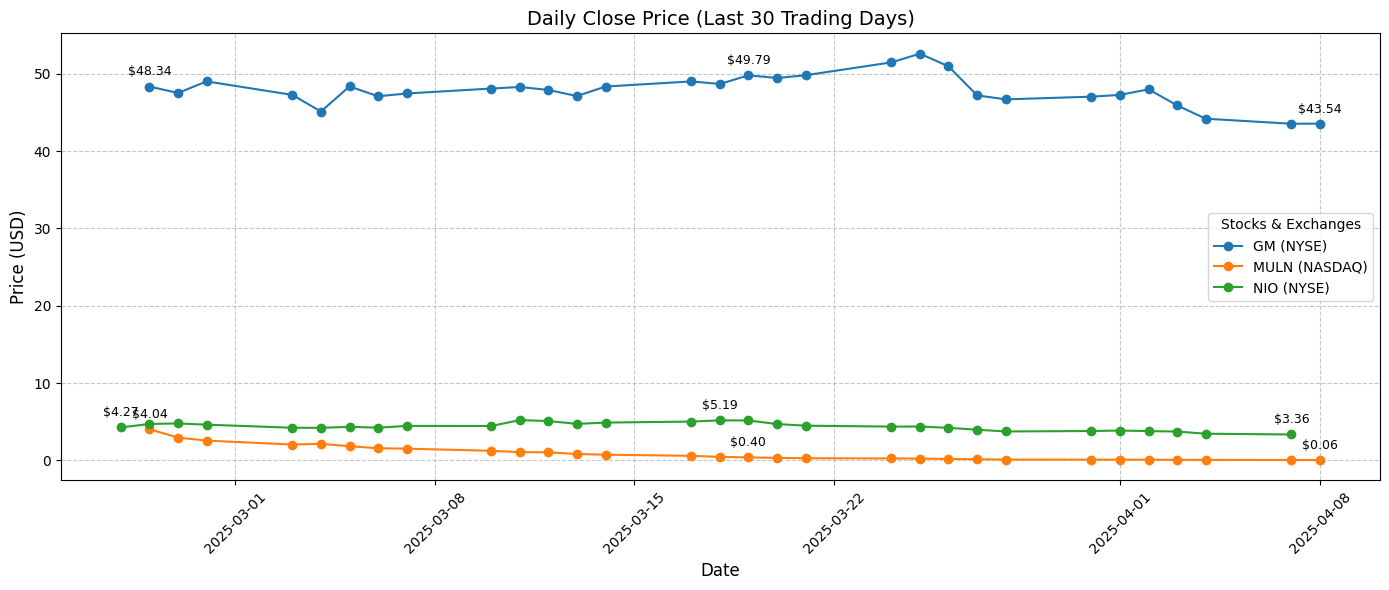

In [6]:
# Import necessary libraries for plotting
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Section 4: Visualize daily closing price (time series plot)

# Set the figure size to make the plot clearer and easier to read
plt.figure(figsize=(14, 6))

# Loop through each stock symbol in our selected stocks
for symbol in stocks:
    # Filter the main DataFrame to get data specific to the current stock
    subset = all_data[all_data['Symbol'] == symbol]

    # Plot the closing price over the date range with markers for each data point
    plt.plot(subset['Date'], subset['Close'],
             label=f"{symbol} ({stocks[symbol]})",  # Include exchange in the label
             marker='o')  # Marker at each point

    # Identify indices for annotations: first, middle, and last data points
    indices = [0, len(subset) // 2, len(subset) - 1]

    # Loop over selected points and annotate with the closing price
    for i in indices:
        plt.annotate(
            f"${subset['Close'].iloc[i]:.2f}",  # Format the price with 2 decimal places and $ sign
            (subset['Date'].iloc[i], subset['Close'].iloc[i]),  # Position of the annotation
            textcoords="offset points",  # Offset the annotation text
            xytext=(0, 8),  # Move annotation 8 points above the point
            ha='center',  # Horizontally center the annotation
            fontsize=9,  # Set font size for readability
            color='black'  # Annotation text color
        )

# Add a descriptive title to the plot
plt.title('Daily Close Price (Last 30 Trading Days)', fontsize=14)

# Label the X-axis
plt.xlabel('Date', fontsize=12)

# Label the Y-axis
plt.ylabel('Price (USD)', fontsize=12)

# Add a legend to differentiate between stocks
plt.legend(title='Stocks & Exchanges')

# Rotate date labels on the X-axis for better readability
plt.xticks(rotation=45)

# Add grid lines for easier visual alignment
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to ensure nothing is cut off
plt.tight_layout()

# Display the plot
plt.show()


## Extra Mile - GitHub + Long-Term Stock Recommendation
This section goes beyond the basic 30-day stock analysis. We:
- Upload the full project to GitHub for collaboration and tracking.
- Perform a **5-year stock trend analysis**.
- Calculate **Compound Annual Growth Rate (CAGR)**.
- Provide a recommendation based on long-term performance.
- Visualize the closing price and 200-day moving average.

In [28]:
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime

def long_term_analysis(stock_symbol, years=5):
    end = datetime.now()
    start = datetime(end.year - years, end.month, end.day)

    stock = yf.download(stock_symbol, start=start, end=end)
    stock['MA200'] = stock['Close'].rolling(window=200).mean()

    plt.figure(figsize=(14,6))
    plt.plot(stock['Close'], label='Close Price')
    plt.plot(stock['MA200'], label='200-Day MA', linestyle='--')
    plt.title(f'{stock_symbol} - {years} Year Performance')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'{stock_symbol}_{years}yr_trend.png')
    plt.show()

    # 💡 Safe and warning-free CAGR calculation
    start_price = stock['Close'].iloc[0]
    end_price = stock['Close'].iloc[-1]
    cagr = (end_price / start_price) ** (1/years) - 1
    return float(cagr)


[*********************100%***********************]  1 of 1 completed


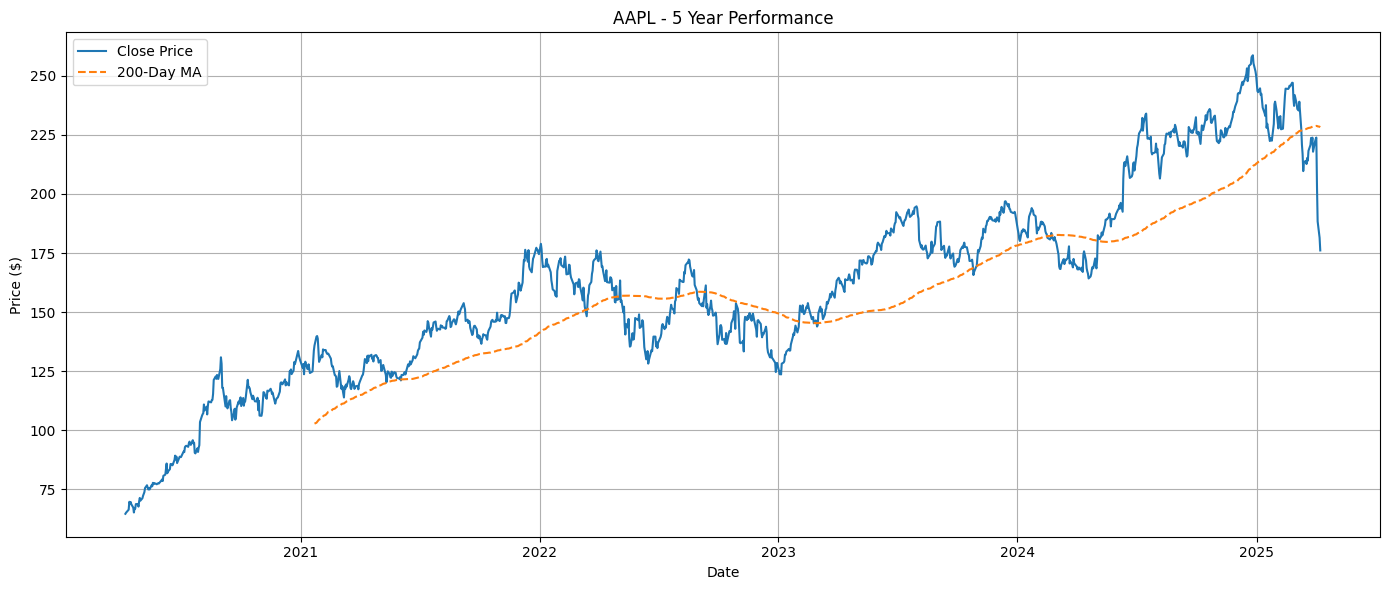

AAPL 5-year CAGR: 22.22%
Strong long-term growth — BUY!


<ipython-input-28-05e68e07f4db>:28: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(cagr)


In [29]:
# 🔍 Analyze long-term performance of a stock (e.g., Apple)
symbol = 'AAPL'  # You can change this to your stock
cagr = long_term_analysis(symbol, years=5)
print(f"{symbol} 5-year CAGR: {cagr*100:.2f}%")

if cagr > 0.12:
    print("Strong long-term growth — BUY!")
elif cagr > 0.05:
    print("Moderate growth — CONSIDER BUYING")
else:
    print("Low growth — RESEARCH MORE BEFORE BUYING")